# PE9.1 — Мульти-модельный агент для Норм-ассистента SINTARIS

Повторяем шаги урока 9.1 на своей теме: вопросы по сертификатам и регламентам медизделий (MDR/IVDR).

| Роль | Модель | Где |
|---|---|---|
| дежурный (intent) | Gemma 4 (Ollama) | локально, цена 0 |
| simple | Gemma 4 (Ollama) | локально, цена 0 |
| medium | gpt-5-mini | OpenAI |
| hard | gpt-5 | OpenAI |
| экзаменатор | gpt-5 | OpenAI |

Ключ OpenAI берётся из `.env` (переменная `OPENAI_API_KEY`) — в код не вставляется.
Локальные шаги требуют запущенного Ollama (`OLLAMA_HOST`, по умолчанию `http://localhost:11434`);
в Google Colab их повторить нельзя, облачные шаги (режим А, экзаменатор) — можно.


In [1]:
# Библиотеки (в локальном .venv уже установлены; в Colab раскомментировать):
# !pip install openai tiktoken python-dotenv pandas matplotlib pillow
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import agent as ag
import run_experiment as rx
print("openai", __import__("openai").__version__, "| Ollama:", ag.OLLAMA_HOST, ag.OLLAMA_MODEL)

openai 3.16.2 | Ollama: http://localhost:11434 gemma4:12b


## Конфигурация ролей и функция вызова модели

Аналог `config` и `call_model` из урока — см. `agent.py`.

In [2]:
import inspect
print(inspect.getsource(ag.Agent.call_model))

    def call_model(self, prompt: str, role: str, namespace: str = "") -> CallResult:
        cfg = self.roles[role]
        key = Cache.key(namespace, role, cfg["model"], cfg["system"], prompt,
                        cfg["max_tokens"], cfg["reasoning_effort"])
        cached = self.cache.get(key)
        if cached is not None:
            return cached
        fn = self.backends.chat_openai if cfg["provider"] == "openai" else self.backends.chat_ollama
        t0 = time.perf_counter()
        text, usage = fn(cfg["model"], cfg["system"], prompt, cfg["max_tokens"], cfg["reasoning_effort"])
        latency = time.perf_counter() - t0
        res = CallResult(
            role=role, provider=cfg["provider"], model=cfg["model"], answer=text.strip(),
            tokens_in=usage["tokens_in"], tokens_out=usage["tokens_out"],
            reasoning_tokens=usage.get("reasoning_tokens", 0), cached_tokens=usage.get("cached_tokens", 0),
            cost_usd=compute_cost(cfg["model"], usage["tokens_i

In [3]:
queries = rx.load_queries()
ctx = rx.Context(rx.HERE / "results", queries)   # кэш results/cache.jsonl: повторные запросы не оплачиваются
print(len(queries), "вопросов; первые три:")
for q in queries[:3]:
    print(f"  {q['id']} [{q['tier']}] {q['question']}")

24 вопросов; первые три:
  S1 [simple] Certificate C-102: validUntil = 2024-11-30, status = Expired. Why is it shown as Expired?
  S2 [simple] What does the abbreviation IVDR stand for?
  S3 [simple] Which German authority is responsible for medical devices under the MPDG?


## Шаг 0. Токенизация: одна фраза на разных языках

In [4]:
rx.step0_tokenization(ctx)

ШАГ 0. Токенизация: одна фраза на разных языках


       язык                                фраза  символов  токенов o200k (gpt-5)  токенов cl100k (gpt-3.5/4)  токенов gemma4:12b
         EN  The certificate expires in 30 days.        35                      8                           8                  10
         RU   Сертификат истекает через 30 дней.        34                     12                          18                  12
         DE Das Zertifikat läuft in 30 Tagen ab.        36                     10                          14                  12
         SL        Certifikat poteče čez 30 dni.        29                     10                          12                  12
RU translit  Sertifikat istekaet cherez 30 dney.        35                     13                          14                  15

Как токенизатор o200k режет фразы (каждый токен в |...|):
  EN          |The|| certificate|| expires|| in|| ||30|| days||.|
  RU          |С||ер||тифик||ат|| ист||ека||ет|| через|| ||30|| дней||.|
  DE          |Das|| Z

[сохранено: results\steps\00_tokenization.txt]



## Шаг 1. Конфигурация: модели, промпты, тарифы

In [5]:
rx.step1_config(ctx)

ШАГ 1. Конфигурация ролей: модели, промпты, тарифы
Тарифы: USD за 1 млн токенов, тариф Standard. Источник: https://developers.openai.com/api/docs/pricing (дата: 2026-09-19)
  роль где работает     модель лимит вывода    reasoning  $/1M вход  $/1M выход
intent       ollama gemma4:12b            5 по умолчанию       0.00         0.0
simple       ollama gemma4:12b          400 по умолчанию       0.00         0.0
medium       openai gpt-5-mini            — по умолчанию       0.25         2.0
  hard       openai      gpt-5            — по умолчанию       1.25        10.0
 judge       openai      gpt-5         4000          low       1.25        10.0

Системный промпт дежурного (intent):
You are the intake assistant of a regulatory helpdesk for medical devices (EU MDR/IVDR, ISO 13485, CE certificates, EUDAMED).
Classify the user's question into exactly one of three tiers:
- simple: a definition or abbreviation, one field of a certificate record (status, date), a single named authority, one f

[сохранено: results\steps\01_config.txt]



## Шаг 2. Пробные запросы: простой и сложный вопрос

In [6]:
rx.step2_call_model(ctx)

ШАГ 2. Функция вызова модели: пробные запросы (простой и сложный вопрос)
--- S1 [simple] Certificate C-102: validUntil = 2024-11-30, status = Expired. Why is it shown as Expired?
дежурный (gemma4:12b, локально): 'simple' → simple   [20.1 с, 222+2 токенов, $0.00000]
ответ модели уровня 'simple' (gemma4:12b, ollama):
The certificate is shown as **Expired** because the current date has surpassed the `validUntil` date of **2024-11-30**.

Under **EU MDR 2017/745**, a certificate remains valid only until its expiration date. Once this date passes, the Notified Body (NB) must issue a new certificate or an extension to maintain compliance. In the context of **EUDAMED** and regulatory tracking:

1.  **Validity Period:** A certificate is legally valid only within the timeframe specified by the Notified Body.
2.  **Compliance Status:** An expired status indicates that the manufacturer no longer has a current certificate from a Notified Body to place the device on the market or maintain its CE mar

[сохранено: results\steps\02_call_model.txt]



## Шаг 3. Проверяем, корректно ли дежурный классифицирует запросы

In [7]:
rx.step3_classifier(ctx)

ШАГ 3. Проверка классификатора: корректно ли дежурный определяет уровень
id ожидали дежурный ответил получили верно  время, с                                                                 вопрос
S1  simple           simple   simple     ✓    20.119 Certificate C-102: validUntil = 2024-11-30, status = Expired. Why is i
S2  simple           simple   simple     ✓    17.241                             What does the abbreviation IVDR stand for?
S3  simple           simple   simple     ✓    16.714 Which German authority is responsible for medical devices under the MP
S4  simple           simple   simple     ✓    16.512          Which authority in Slovenia is competent for medical devices?
S5  simple           simple   simple     ✓    16.838                                               What is a notified body?
S6  simple           simple   simple     ✓    19.738 Certificate Z-17: validUntil = 2026-11-15, status = Expiring soon. Why
S7  simple           simple   simple     ✓    16.457       

[сохранено: results\steps\03_classifier.txt]



## Шаг 4. Режим А — только мощная модель (gpt-5)

In [8]:
rx.step4_mode_a(ctx)

ШАГ 4. Режим А: все вопросы — только в мощную модель (gpt-5)
id уровень модель  вход  выход  рассужд.  стоимость $  время, с
S1  simple  gpt-5   105   2804      2624      0.02817    36.134
S2  simple  gpt-5    85    295       256      0.00306     2.923
S3  simple  gpt-5    89   1837      1728      0.01848    16.935
S4  simple  gpt-5    86   2651      2560      0.02662    24.623
S5  simple  gpt-5    82   1972      1728      0.01982    34.308
S6  simple  gpt-5   102   1553      1472      0.01566    21.013
S7  simple  gpt-5    85   3308      2816      0.03319    30.602
S8  simple  gpt-5    95    504       448      0.00516     4.944
M1  medium  gpt-5    91   4035      3456      0.04046    31.135
M2  medium  gpt-5    95   2449      2304      0.02461    43.754
M3  medium  gpt-5    94   3784      3392      0.03796    35.668
M4  medium  gpt-5    90   3947      3328      0.03958    33.186
M5  medium  gpt-5    90   4762      4288      0.04773    63.308
M6  medium  gpt-5    89   2320      1984   

[сохранено: results\steps\04_mode_A_strong_only.txt]



## Шаг 5. Режим Б — мультимодельность (дежурный + модель по уровню)

In [9]:
rx.step5_mode_b(ctx)

ШАГ 5. Режим Б: мультимодельность — дежурный + модель по уровню
id ожидали дежурный модель ответа  вход  выход  рассужд.  стоимость $ (с дежурным)  время, с (с дежурным)
S1  simple   simple    gemma4:12b   130    119         0                   0.00000                 72.238
S2  simple   simple    gemma4:12b   104     60         0                   0.00000                 38.156
S3  simple   simple    gemma4:12b   108    112         0                   0.00000                 49.478
S4  simple   simple    gemma4:12b   105    113         0                   0.00000                 49.647
S5  simple   simple    gemma4:12b   101    344         0                   0.00000                105.247
S6  simple   simple    gemma4:12b   126    268         0                   0.00000                 90.251
S7  simple   simple    gemma4:12b   103    387         0                   0.00000                114.367
S8  simple   simple    gemma4:12b   114    199         0                   0.00000      

[сохранено: results\steps\05_mode_B_multimodel.txt]



## Шаг 6. Экзаменатор — качество ответов вслепую

In [10]:
rx.step6_judge(ctx)

ШАГ 6. Экзаменатор: оценка качества ответов вслепую (1–5)
id уровень  Б: модель  оценка А  оценка Б                                              комментарий к Б
S1  simple gemma4:12b         5         4 Core reason is correct but lacks specific MDR article citati
S2  simple gemma4:12b         5         2 Expands IVDR correctly and cites 2017/746, but misstates the
S3  simple gemma4:12b         5         3 Identifies BfArM correctly but adds misleading points (e.g.,
S4  simple gemma4:12b         4         2 Wrong authority name and abbreviation (should be JAZMP: Javn
S5  simple gemma4:12b         5         2 Basic definition is right, but key citations and details are
S6  simple gemma4:12b         4         2 Correct that it’s near expiry, but adds misleading MDR/IVDR,
S7  simple gemma4:12b         5         3 Partially correct definition and content, but cites wrong pr
S8  simple gemma4:12b         5         1 Incorrect: MDR Article 56(2) sets a maximum validity of 5 ye
M1  medium gpt-

[сохранено: results\steps\06_judge.txt]


## Шаг 7. Сравнение двух результатов

In [11]:
summary = rx.step7_summary(ctx)
rx.save_results(ctx)

ШАГ 7. Сравнение: только мощная модель (А) против мультимодельности (Б)
                   показатель А: только gpt-5 Б: мультимодельность разница
                 стоимость, $         0.76525              0.40541    -47%
             время, с (сумма)           991.4               1543.7    +56%
 время, с (среднее на вопрос)            41.3                 64.3        
         токенов вход / выход    2326 / 76234         7512 / 55199        
средняя оценка качества (1–5)            4.67                 3.75   -0.92

Режим Б — кто отвечал:
  gemma4:12b    8 вопросов, $0.00000, 449 с
  gpt-5-mini    7 вопросов, $0.03302, 206 с
  gpt-5         9 вопросов, $0.37240, 454 с
  дежурный (gemma4:12b): 24 классификаций, $0, 435 с

Ошибки маршрутизации (id: ожидали → получили; оценка А / Б):
  M3: medium → hard; оценка 5 / 5

ВЫВОД: Мультимодельность дешевле на 47% при среднем качестве 3.75 против 4.67; время больше на 56% (локальная модель работает на CPU ноутбука).


[сохранено: results\steps\07_summary.txt]


Сохранено: D:\Projects\workspace\zerocoder\Perr9.1\results\summary.json, runs.csv, answers.md

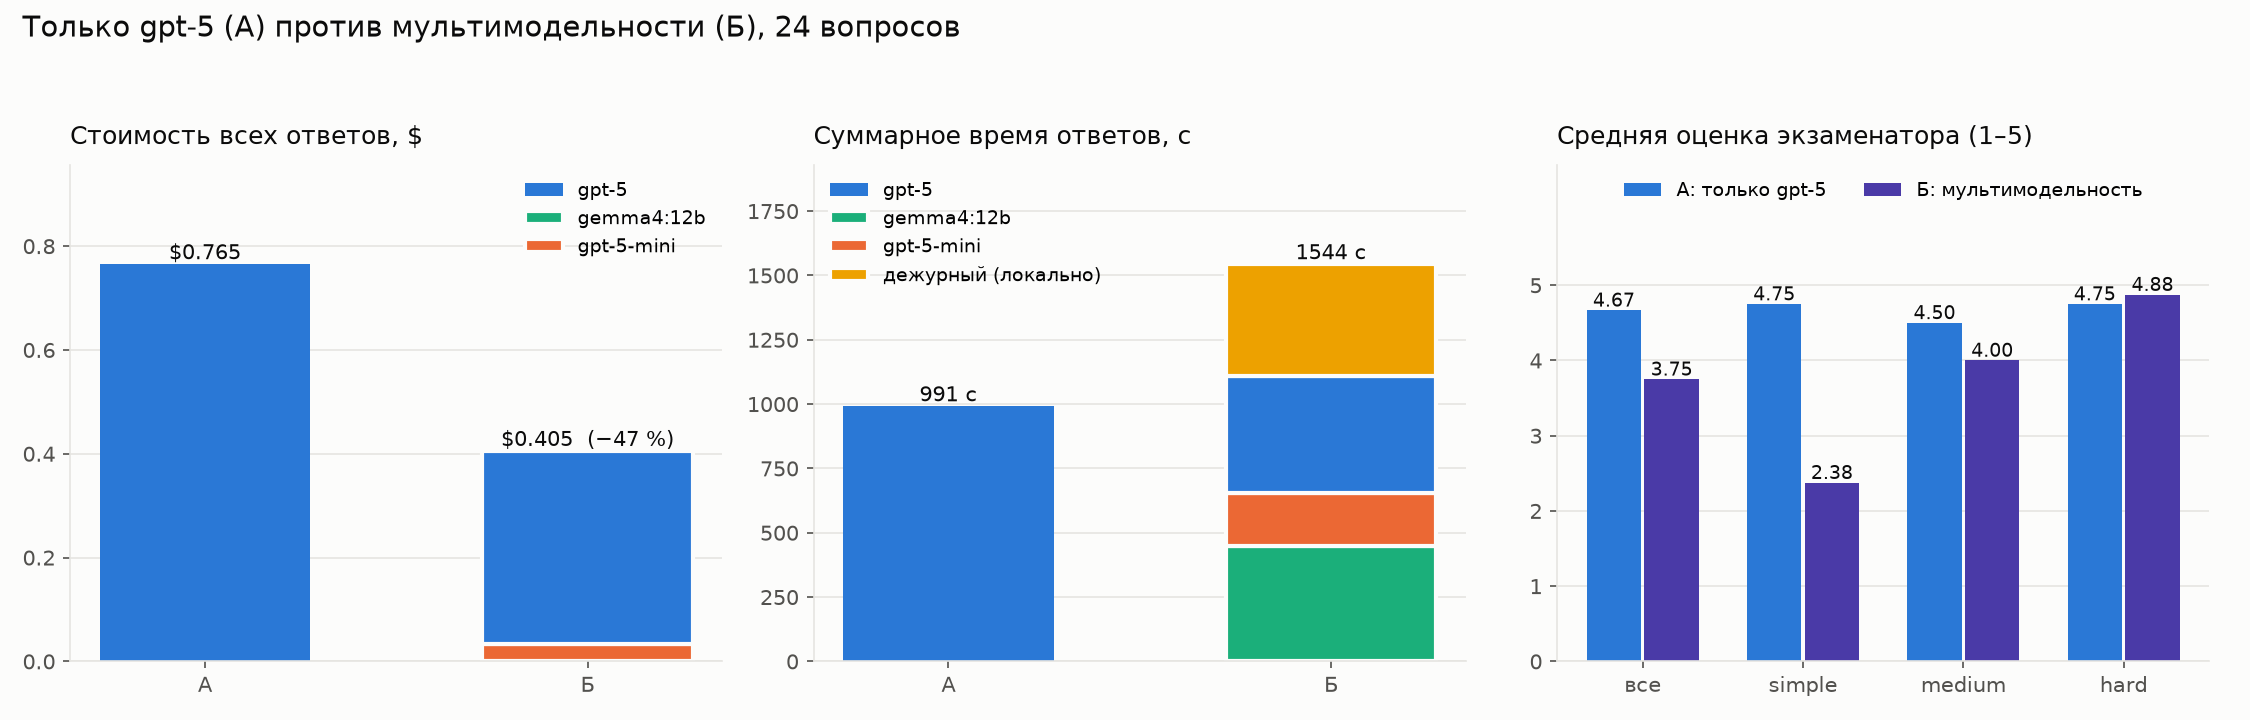

In [12]:
from IPython.display import Image, display
import make_screenshots as ms
ms.chart_comparison(summary, rx.HERE / "results" / "comparison.png")
display(Image(filename=str(rx.HERE / "results" / "comparison.png")))